# I/O

In this example, we will show how to load various input types and to extract relevance informations

In [1]:
import numpy as np
from copy import deepcopy
from ase.io import read
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor

## for plotting if needed
import matplotlib
import matplotlib.pyplot as plt

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT)) 

from muonscripts.constants import constants
from muonscripts.io_tools.read import read_cif
from muonscripts.io_tools.read import read_from_file

import muonscripts.io_tools as ios
import muonscripts.io_tools.read_qe  as qe
import muonscripts.io_tools.read_elk  as elk

from muonscripts.io_tools.load_relax import load_relax
from muonscripts.io_tools.load_relax import save_relax_results
from muonscripts.io_tools.load_relax import load_relax_results
from muonscripts.io_tools.find_qe_files import select_groups
from muonscripts.io_tools.find_qe_files import get_relax_after_run
from muonscripts.io_tools.find_qe_files import print_relax_summary
from muonscripts.io_tools.find_qe_files import load_relax_from_folder

from muonscripts.io_tools.qe import relabel_qe_species
from muonscripts.io_tools.qe import build_species_rename_map

from muonscripts.io_tools.write_pw_input import write_pw_input


from muonscripts.muon_tools import contact_field
from muonscripts.muon_tools.muonic_dataframe import get_dataframe
from muonscripts.muon_tools.distortions.distortions import get_structs
from muonscripts.muon_tools.aiida_muon.clustering_report import print_clustering_summary
from muonscripts.muon_tools.aiida_muon.clustering import get_clustering_after_run_from_data

from muonscripts.muesr_tools.local_fields import pfields, rfields
from muonscripts.muesr_tools.utils import _extract_muon, get_atom_kinds

from muonscripts.muon_tools.nearby import _group_fmt
from muonscripts.muon_tools.nearby import nearby_atom
from muonscripts.muon_tools.nearby import print_muon_table
from muonscripts.muon_tools.nearby import get_group_nearby_atom

from muonscripts.symmetry import wyckoff as wyckoff
from muonscripts.symmetry.sites import get_equivalent_sites
from muonscripts.symmetry.magnetism import make_collinear_getmag_kind
from muonscripts.symmetry.magnetism import create_starting_mag_kindlist

from muonscripts.undi_tools.celio_signal import get_signal

from muonscripts.plot_tools.muon import fancy_style_axes

print(f"Planck Constant: {constants.H_PLANCK} J/s")
print(f"Muon Gyromagnetic Ratio: {constants.MUON_GYROMAGNETIC_RATIO} rad/(s T)")
# ROOT, sys.path

Planck Constant: 6.62607015e-34 J/s
Muon Gyromagnetic Ratio: 851615459.5446056 rad/(s T)


In [3]:
import os
dpath = './data'

load input structure formats

In [4]:
file=os.path.join(dpath, 'CaF2.cif')
read_cif(file)
read_from_file(file)

/home/misah/.virtualenvs/pyqm/lib/python3.10/site-packages/ase/io/cif.py:411: UserWarning: crystal system 'cubic' is not interpreted for space group Spacegroup(225, setting=1). This may result in wrong setting!
  warnings.warn(


Atoms(symbols='Ca4F8', pbc=True, cell=[5.45095, 5.45095, 5.45095], spacegroup_kinds=...)

In [5]:
file=os.path.join(dpath, 'CaF2.vasp')
read_cif(file)
read_from_file(file)

Atoms(symbols='Ca4F8', pbc=True, cell=[5.4509501457, 5.4509501457, 5.4509501457])

In [6]:
file=os.path.join(dpath, 'CaF2.vasp')
Structure.from_file(file)

Structure Summary
Lattice
    abc : 5.4509501457 5.4509501457 5.4509501457
 angles : 90.0 90.0 90.0
 volume : 161.96330486922204
      A : np.float64(5.4509501457) np.float64(0.0) np.float64(0.0)
      B : np.float64(0.0) np.float64(5.4509501457) np.float64(0.0)
      C : np.float64(0.0) np.float64(0.0) np.float64(5.4509501457)
    pbc : True True True
PeriodicSite: Ca (2.725, 2.725, 2.725) [0.5, 0.5, 0.5]
PeriodicSite: Ca (2.725, 0.0, 0.0) [0.5, 0.0, 0.0]
PeriodicSite: Ca (0.0, 2.725, 0.0) [0.0, 0.5, 0.0]
PeriodicSite: Ca (0.0, 0.0, 2.725) [0.0, 0.0, 0.5]
PeriodicSite: F (1.363, 4.088, 4.088) [0.25, 0.75, 0.75]
PeriodicSite: F (4.088, 1.363, 1.363) [0.75, 0.25, 0.25]
PeriodicSite: F (4.088, 1.363, 4.088) [0.75, 0.25, 0.75]
PeriodicSite: F (1.363, 4.088, 1.363) [0.25, 0.75, 0.25]
PeriodicSite: F (4.088, 4.088, 1.363) [0.75, 0.75, 0.25]
PeriodicSite: F (1.363, 1.363, 4.088) [0.25, 0.25, 0.75]
PeriodicSite: F (1.363, 1.363, 1.363) [0.25, 0.25, 0.25]
PeriodicSite: F (4.088, 4.088, 4.088) 

load QE input/output file

In [7]:
file = os.path.join(dpath, 'relax.in')
ios.read_qe.read_in(file)

Atoms(symbols='HCa32F64', pbc=True, cell=[10.9019002914, 10.9019002914, 10.9019002914], initial_magmoms=...)

In [8]:
file = os.path.join(dpath, 'relax.out')
ios.read_qe.read_out(file)

Atoms(symbols='HCa32F64', pbc=True, cell=[10.901900350679567, 10.901900350679567, 10.901900350679567], calculator=SinglePointDFTCalculator(...))

In [9]:
file = os.path.join(dpath, 'relax.in')
qe.read_in(file)

Atoms(symbols='HCa32F64', pbc=True, cell=[10.9019002914, 10.9019002914, 10.9019002914], initial_magmoms=...)

In [10]:
file = os.path.join(dpath, 'relax.out')
qe.read_out(file)

Atoms(symbols='HCa32F64', pbc=True, cell=[10.901900350679567, 10.901900350679567, 10.901900350679567], calculator=SinglePointDFTCalculator(...))

In [11]:
file = os.path.join(dpath, 'relax.in')
read_from_file(file, format='espresso-in')

Atoms(symbols='HCa32F64', pbc=True, cell=[10.9019002914, 10.9019002914, 10.9019002914], initial_magmoms=...)

In [12]:
file = os.path.join(dpath, 'relax.out')
atoms = read_from_file(file, format='espresso-out', index=-1)

convert ase to pymatgen

In [13]:
rlx = AseAtomsAdaptor.get_structure(atoms)
print(rlx)

Full Formula (Ca32 H1 F64)
Reduced Formula: Ca32HF64
abc   :  10.901900  10.901900  10.901900
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (97)
  #  SP            a          b          c
---  ----  ---------  ---------  ---------
  0  Ca     0.272299   0.272299   0.250002
  1  Ca     0.749781   0.749781   0.749999
  2  Ca     0.744938   0.744938   0.250004
  3  Ca     0.249817   0.249817   0.749997
  4  Ca     0.749559   0.250352   0.749998
  5  Ca     0.249065   0.750469   0.250003
  6  Ca     0.250352   0.749559   0.749998
  7  Ca     0.750469   0.249065   0.250003
  8  Ca     0.250617   0.502354   0.502636
  9  Ca     0.747644  -0.000615  -0.002641
 10  Ca     0.747649  -0.000616   0.502637
 11  Ca     0.250617   0.50236   -0.00264
 12  Ca     0.750042   0.499961  -0.000706
 13  Ca     0.253652  -0.003647   0.502124
 14  Ca     0.25365   -0.003646  -0.00211
 15  Ca     0.750043   0.499959   0.500702
 16  Ca     0.502354   0.250617   0.50263

convert pymatgen to ase

In [14]:
file=os.path.join(dpath, 'CaF2.vasp')
st = Structure.from_file(file)
atoms = AseAtomsAdaptor.get_atoms(st)
atoms

MSONAtoms(symbols='Ca4F8', pbc=True, cell=[5.4509501457, 5.4509501457, 5.4509501457])

load QE efg tensors from gipaw output file

In [15]:
file = os.path.join(dpath, 'V3Si_QE_EFG3x3x3_SITE_A.OUT')
efg_tensors = qe.read_efg(file)

efg_tensors[0]

array([[-8.62804611e+19,  0.00000000e+00, -1.14694029e+20],
       [ 0.00000000e+00, -2.97322139e+20,  0.00000000e+00],
       [-1.14694029e+20,  0.00000000e+00,  3.83602600e+20]])

load ELK output files: (geometry and EFG tensors)

In [16]:
file = os.path.join(dpath, 'MnSi_GEOMETRY.OUT')
elk.read_geom(file)

Atoms(symbols='Mn4Si4', pbc=True, cell=[4.566199937664733, 4.566199937664733, 4.566199937664733], initial_magmoms=...)

In [17]:
file = os.path.join(dpath, 'MnSi_EFG.OUT')
efg_tensors = elk.read_efg(file)

efg_tensors[0]

array([[-3.02274846e+04, -1.54534901e+20, -1.54534901e+20],
       [-1.54534901e+20, -3.12190144e+05, -1.54534901e+20],
       [-1.54534901e+20, -1.54534901e+20,  3.42417629e+05]])

remove numerical noise in efg tensors

In [18]:
remove_efg_noise=True
efg_noise_threshold=1e-8

tensors = []
for tensor in efg_tensors:
    if remove_efg_noise:
        max_element = np.max(np.abs(tensor))
        if max_element > 0:
            tensor[np.abs(tensor) < efg_noise_threshold * max_element] = 0.0
    tensors.append(tensor)

tensors[0]

array([[ 0.00000000e+00, -1.54534901e+20, -1.54534901e+20],
       [-1.54534901e+20,  0.00000000e+00, -1.54534901e+20],
       [-1.54534901e+20, -1.54534901e+20,  0.00000000e+00]])

move muon to origin, useful for hyperfine contact field calculations with QE

In [19]:
file = os.path.join(dpath, 'relax.out')
atoms = read_from_file(file, format='espresso-out', index=-1)

rlx = AseAtomsAdaptor.get_structure(atoms)

# get muon
mupos_rlx = rlx.frac_coords[rlx.atomic_numbers.index(1)]

rlx.translate_sites(
    range(rlx.num_sites), -mupos_rlx, frac_coords=True, to_unit_cell=False
)

for site in rlx:
    print(f"{site.species_string:<3} {site.a:14.9f} {site.b:14.9f} {site.c:14.9f}")

Ca     0.147298639    0.147298639   -0.000010350
Ca     0.624780375    0.624780375    0.499986135
Ca     0.619938009    0.619938009   -0.000008517
Ca     0.124817109    0.124817109    0.499984411
Ca     0.624558611    0.125352299    0.499985431
Ca     0.124064486    0.625468576   -0.000009340
Ca     0.125352299    0.624558611    0.499985431
Ca     0.625468576    0.124064486   -0.000009340
Ca     0.125617131    0.377354259    0.252623661
Ca     0.622643429   -0.125615103   -0.252653414
Ca     0.622649030   -0.125615701    0.252624146
Ca     0.125616536    0.377359862   -0.252652939
Ca     0.625041660    0.374960563   -0.250718077
Ca     0.128651806   -0.128647602    0.252111058
Ca     0.128649988   -0.128645781   -0.252122028
Ca     0.625042902    0.374959319    0.250689676
Ca     0.377354259    0.125617131    0.252623661
Ca    -0.125615103    0.622643429   -0.252653414
Ca    -0.125615701    0.622649030    0.252624146
Ca     0.377359862    0.125616536   -0.252652939
Ca    -0.128645781  

compute spin density at muon site from QE (pp) .XSF file (up & down .xsf files)

In [20]:
up_file = 'Fe2P_QE_spinup_Astar.XSF'
up_file = 'Fe2P_QE_spinup_A.XSF'
up_file = os.path.join(dpath, up_file)
dw_file = 'Fe2P_QE_spindw_Astar.XSF'
dw_file = 'Fe2P_QE_spindw_A.XSF'
dw_file = os.path.join(dpath, dw_file)

sp_density, B_c = contact_field.field_at_muon(up_file, dw_file)

print(f'calculated spin density at muon site = {sp_density: .6e} (bohr^-3) | contact field = {B_c: .5f} (Tesla)')


calculated spin density at muon site = -8.153000e-03 (bohr^-3) | contact field = -0.42746 (Tesla)


calculated local field at the muon site: Fe2P

In [21]:
filename = 'Fe2P.cif'
filename = os.path.join(dpath, filename)
st = Structure.from_file(filename)

/home/misah/.virtualenvs/pyqm/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


In [22]:
# Identify atom kinds
# There are two distincts Fe atoms, Fe1 and Fe2 in Fe2P

atm_kinds = get_atom_kinds(st)

print("\nAtom kinds:")
for kind, indices in atm_kinds.items():
    print(f"{kind}: {indices}")


print("\nFe1 indices:")
print(atm_kinds["Fe1"])
print("\nFe2 indices:")
print(atm_kinds["Fe2"])


Atom kinds:
Fe1: [0, 1, 2]
Fe2: [3, 4, 5]
P1: [6, 7]
P2: [8]

Fe1 indices:
[0, 1, 2]

Fe2 indices:
[3, 4, 5]


In [23]:
print("\nFe1 fractional coordinates:")

for i in atm_kinds["Fe1"]:
    print(
        f"index = {i:3d}   "
        f"frac = {st.frac_coords[i]}"
    )

print("\nFe2 fractional coordinates:")

for i in atm_kinds["Fe2"]:
    print(
        f"index = {i:3d}   "
        f"frac = {st.frac_coords[i]}"
    )


Fe1 fractional coordinates:
index =   0   frac = [0.256 0.    0.   ]
index =   1   frac = [0.744 0.744 0.   ]
index =   2   frac = [0.    0.256 0.   ]

Fe2 fractional coordinates:
index =   3   frac = [0.589 0.    0.5  ]
index =   4   frac = [0.411 0.411 0.5  ]
index =   5   frac = [0.    0.589 0.5  ]


In [24]:
# Magnetic moment directions
#

Fe1_dir_001 = np.array([0.0, 0.0, 0.84])  # muB
Fe2_dir_001 = np.array([0.0, 0.0, 2.22])  # muB

print("\nMoment magnitudes:")
print("|Fe1_dir_001| =", np.linalg.norm(Fe1_dir_001))
print("|Fe2_dir_001| =", np.linalg.norm(Fe2_dir_001))


Moment magnitudes:
|Fe1_dir_001| = 0.84
|Fe2_dir_001| = 2.22


In [25]:
# Construct magnetic structures

magmoms  = np.zeros((len(st), 3))

# FM [001]
magmoms[atm_kinds["Fe1"]] = Fe1_dir_001
magmoms[atm_kinds["Fe2"]] = Fe2_dir_001

magmoms

array([[0.  , 0.  , 0.84],
       [0.  , 0.  , 0.84],
       [0.  , 0.  , 0.84],
       [0.  , 0.  , 2.22],
       [0.  , 0.  , 2.22],
       [0.  , 0.  , 2.22],
       [0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  ]])

In [26]:
mupos = np.array([0.002, 0.328, 0.501])
include_equiv = True
contact_field_value = -0.42746 # in Tesla

# calculated field, using pristine structure

fields_contribs = pfields(
    structure=st.copy(),
    magmoms=magmoms,
    muon_pos=mupos,
    cont_field=contact_field_value,  # calculated above
    include_equivalent_sites=include_equiv,
)

# field contributions container
fields_contribs

LocalFieldResults(total=array([[ 2.25621745e-03, -3.98492345e-03, -4.60537734e-01],
       [ 4.57915366e-03, -3.85201008e-05, -4.60537734e-01],
       [ 2.32293622e-03,  3.94640335e-03, -4.60537734e-01]]), dipolar=array([[ 2.25621745e-03, -3.98492345e-03, -3.79958765e-01],
       [ 4.57915366e-03, -3.85201008e-05, -3.79958765e-01],
       [ 2.32293622e-03,  3.94640335e-03, -3.79958765e-01]]), lorentz=array([[0.        , 0.        , 0.34688103],
       [0.        , 0.        , 0.34688103],
       [0.        , 0.        , 0.34688103]]), contact=array([[-0.     , -0.     , -0.42746],
       [-0.     , -0.     , -0.42746],
       [-0.     , -0.     , -0.42746]]), dipolar_tot=array([[ 2.25621745e-03, -3.98492345e-03, -3.30777336e-02],
       [ 4.57915366e-03, -3.85201008e-05, -3.30777336e-02],
       [ 2.32293622e-03,  3.94640335e-03, -3.30777336e-02]]), total_norm=array([0.4605605, 0.4605605, 0.4605605]), dipolar_norm=array([0.37998636, 0.37998636, 0.37998636]), lorentz_norm=array([0.34688

In [27]:
REF_EXP_LOCAL_FIELD = 0.3963 # Tesla

fields = ["dipolar", "lorentz", "contact", "dipolar_tot", "total"]

for i, pos in enumerate(fields_contribs.muon_positions):
    print(
        f"\nSite {i+1}  "
        f"position = ({pos[0]:.3f}, {pos[1]:.3f}, {pos[2]:.3f})"
    )

    for name in fields:
        vec = getattr(fields_contribs, name)[i]
        mag = np.linalg.norm(vec)

        print(
            f"  {name:12s}: "
            f"[{vec[0]: .8f}, {vec[1]: .8f}, {vec[2]: .8f}]  (Tesla) "
            f"|B| = {mag:.8f} (Tesla)"
        )

    total_field = fields_contribs.total_norm[i]
    diff = total_field - REF_EXP_LOCAL_FIELD
    status = "Overestimation" if diff >= 0 else "Underestimation"
    accuracy = np.abs(diff) / REF_EXP_LOCAL_FIELD

    print(
        f"  Observed field     = {REF_EXP_LOCAL_FIELD:.8f} (Tesla)"
    )
    print(
        f"  Calculated field   = {total_field:.8f} (Tesla)"
    )
    print(
        f"  {status:<18} = {accuracy * 100:.1f} %"
    )


Site 1  position = (0.002, 0.328, 0.501)
  dipolar     : [ 0.00225622, -0.00398492, -0.37995876]  (Tesla) |B| = 0.37998636 (Tesla)
  lorentz     : [ 0.00000000,  0.00000000,  0.34688103]  (Tesla) |B| = 0.34688103 (Tesla)
  contact     : [-0.00000000, -0.00000000, -0.42746000]  (Tesla) |B| = 0.42746000 (Tesla)
  dipolar_tot : [ 0.00225622, -0.00398492, -0.03307773]  (Tesla) |B| = 0.03339321 (Tesla)
  total       : [ 0.00225622, -0.00398492, -0.46053773]  (Tesla) |B| = 0.46056050 (Tesla)
  Observed field     = 0.39630000 (Tesla)
  Calculated field   = 0.46056050 (Tesla)
  Overestimation     = 16.2 %

Site 2  position = (0.326, 0.998, 0.499)
  dipolar     : [ 0.00457915, -0.00003852, -0.37995876]  (Tesla) |B| = 0.37998636 (Tesla)
  lorentz     : [ 0.00000000,  0.00000000,  0.34688103]  (Tesla) |B| = 0.34688103 (Tesla)
  contact     : [-0.00000000, -0.00000000, -0.42746000]  (Tesla) |B| = 0.42746000 (Tesla)
  dipolar_tot : [ 0.00457915, -0.00003852, -0.03307773]  (Tesla) |B| = 0.03339321 

Get and include structural distortions for symmetry equivalent site/structures

In [28]:
file = 'host_mag.cif'
file = os.path.join(dpath, file)
host_ase  = read_from_file(file)

In [29]:
file = 'relax_mag.in'
file = os.path.join(dpath, file)
inp_ase  = read_from_file(file, format="espresso-in")
inp_ase2 = inp_ase.copy() 

In [30]:
file = 'relax_mag.out'
file = os.path.join(dpath, file)
rlx_ase  = read_from_file(file, format="espresso-out", index=-1)
rlx_ase2 = rlx_ase.copy()

In [31]:
host_lattice = AseAtomsAdaptor.get_structure(host_ase)
p_st = AseAtomsAdaptor.get_structure(inp_ase)
rlx_st = AseAtomsAdaptor.get_structure(rlx_ase)

In [32]:
results = get_structs(
    p_st=p_st,
    rlx_st=rlx_st,
    host_st=host_lattice,
    min_distance=0.5
)
# results

In [33]:
sc_matrix = [
    [2, 0, 0], 
    [0, 2, 0], 
    [0, 0, 3]
    ]


for i, site in enumerate(results):
    sc_frac = np.dot(site.frac_pos, sc_matrix) % 1
    sc_str = " ".join(f"{x:7.4f}" for x in site.frac_pos)
    prim_str = " ".join(f"{x:7.4f}" for x in sc_frac)
    flag = "orig" if site.is_original else ("magn " if site.is_magnetically_equivalent else "struc")
    status = "ok" if site.ok else "FAIL"
    print(f"[{i:2d}] ({sc_str}) -> ({prim_str})  {flag:5s} {status}")

[ 0] ( 0.0011  0.1641  0.1667) -> ( 0.0023  0.3282  0.5000)  orig  ok
[ 1] ( 0.1630  0.9989  0.8333) -> ( 0.3259  0.9977  0.5000)  magn  ok
[ 2] ( 0.8359  0.8370  0.1667) -> ( 0.6718  0.6741  0.5000)  magn  ok
[ 3] ( 0.0011  0.1641  0.8333) -> ( 0.0023  0.3282  0.5000)  magn  ok
[ 4] ( 0.1630  0.9989  0.1667) -> ( 0.3259  0.9977  0.5000)  magn  ok
[ 5] ( 0.8359  0.8370  0.8333) -> ( 0.6718  0.6741  0.5000)  magn  ok


In [34]:
fields = ["dipolar", "lorentz", "contact", "dipolar_tot", "total"]

total_vecs = []
for idx, site in enumerate(results):
    if site.structure is not None:
        fields_contribs2 = rfields(
            p_st=host_lattice,
            magmoms=magmoms,
            sc_mat=sc_matrix,
            r_supst=site.structure,
            cont_field=contact_field_value,
            # muon_label: str = "H",
        )

        total_vecs.append(fields_contribs2.total[0])

        sc_frac = np.dot(site.frac_pos, sc_matrix) % 1
        sc_str = " ".join(f"{x:7.4f}" for x in site.frac_pos)
        prim_str = " ".join(f"{x:7.4f}" for x in sc_frac)

        flag = "orig" if site.is_original else ("magn " if site.is_magnetically_equivalent else "struc")
        status = "ok" if site.ok else "FAIL"

        print(f"\n[{idx:2d}] ({sc_str}) -> ({prim_str})  {flag:5s} {status}")

        for i, pos in enumerate(fields_contribs2.muon_positions):

            # print(
            #     f"\nSite {i+1}  "
            #     f"position = ({pos[0]:.3f}, {pos[1]:.3f}, {pos[2]:.3f})"
            # )
            

            for name in fields:
                vec = getattr(fields_contribs2, name)[i]
                mag = np.linalg.norm(vec)

                print(
                    f"  {name:12s}: "
                    f"[{vec[0]: .8f}, {vec[1]: .8f}, {vec[2]: .8f}]  (Tesla) "
                    f"|B| = {mag:.8f} (Tesla)"
                )

            total_field = fields_contribs2.total_norm[i]
            diff = total_field - REF_EXP_LOCAL_FIELD
            status = "Overestimation" if diff >= 0 else "Underestimation"
            accuracy = np.abs(diff) / REF_EXP_LOCAL_FIELD

            print(
                f"  Observed field     = {REF_EXP_LOCAL_FIELD:.8f} (Tesla)"
            )
            print(
                f"  Calculated field   = {total_field:.8f} (Tesla)"
            )
            print(
                f"  {status:<18} = {accuracy * 100:.1f} %"
            )


[ 0] ( 0.0011  0.1641  0.1667) -> ( 0.0023  0.3282  0.5000)  orig  ok
  dipolar     : [ 0.00000724, -0.00001300, -0.17994109]  (Tesla) |B| = 0.17994109 (Tesla)
  lorentz     : [ 0.00000000,  0.00000000,  0.34687449]  (Tesla) |B| = 0.34687449 (Tesla)
  contact     : [-0.00000000, -0.00000000, -0.42746000]  (Tesla) |B| = 0.42746000 (Tesla)
  dipolar_tot : [ 0.00000724, -0.00001300,  0.16693340]  (Tesla) |B| = 0.16693340 (Tesla)
  total       : [ 0.00000724, -0.00001300, -0.26052660]  (Tesla) |B| = 0.26052660 (Tesla)
  Observed field     = 0.39630000 (Tesla)
  Calculated field   = 0.26052660 (Tesla)
  Underestimation    = 34.3 %

[ 1] ( 0.1630  0.9989  0.8333) -> ( 0.3259  0.9977  0.5000)  magn  ok
  dipolar     : [ 0.00597928, -0.00562851, -0.41473004]  (Tesla) |B| = 0.41481133 (Tesla)
  lorentz     : [ 0.00000000,  0.00000000,  0.34687449]  (Tesla) |B| = 0.34687449 (Tesla)
  contact     : [-0.00000000, -0.00000000, -0.42746000]  (Tesla) |B| = 0.42746000 (Tesla)
  dipolar_tot : [ 0.0059

In [35]:
total_vecs = np.array(total_vecs)

# 1. Component-wise Mean & Standard Deviation
vec_mean = np.mean(total_vecs, axis=0)
vec_std = np.std(total_vecs, axis=0, ddof=1)  # Sample standard deviation (N - 1)

# 2. Individual Vector Magnitudes
magnitudes = np.linalg.norm(total_vecs, axis=1)
mag_mean = np.mean(magnitudes)
mag_std = np.std(magnitudes, ddof=1)

# 3. Reference Field Diagnostics
mag_of_mean = np.linalg.norm(vec_mean)

# Difference and accuracy for vector mean magnitude
diff_mean = mag_of_mean - REF_EXP_LOCAL_FIELD
status_mean = "Overestimation" if diff_mean >= 0 else "Underestimation"
accuracy_mean = (np.abs(diff_mean) / REF_EXP_LOCAL_FIELD) * 100

# Difference and accuracy for scalar mean of magnitudes
diff_scalar = mag_mean - REF_EXP_LOCAL_FIELD
status_scalar = "Overestimation" if diff_scalar >= 0 else "Underestimation"
accuracy_scalar = (np.abs(diff_scalar) / REF_EXP_LOCAL_FIELD) * 100

# --- Clean Formatted Print Output ---
divider = "=" *70

print(f"\n{divider}")
print(f"{'VECTOR FIELD STATISTICS (Tesla)':^62}")
print(f"{divider}\n")

# Individual Vectors Table
print("Individual Field Vectors and Magnitudes:")
print("-" * 70)
print(f"{'Index':<7} | {'Bx (T)':^13} | {'By (T)':^13} | {'Bz (T)':^13} | {'|B| (T)':^11}")
print("-" * 70)
for idx, (vec, mag) in enumerate(zip(total_vecs, magnitudes)):
    print(f" #{idx:<5d} | {vec[0]:13.6e} | {vec[1]:13.6e} | {vec[2]:13.6e} | {mag:11.6f}")
print("-" * 70)

# Component-wise Summary
print("\n--- Component-wise Averages ---")
print(f"Mean Vector [Bx, By, Bz] : [{vec_mean[0]:13.6e}, {vec_mean[1]:13.6e}, {vec_mean[2]:13.6e}] T")
print(f"Std Dev     [Bx, By, Bz] : [{vec_std[0]:13.6e}, {vec_std[1]:13.6e}, {vec_std[2]:13.6e}] T")

# Magnitude Summary
print("\n--- Scalar Magnitude Summary ---")
print(f"Magnitude of Mean Vector (||<B>||) : {mag_of_mean:.8f} T")
print(f"Mean of Magnitudes       (<||B||>) : {mag_mean:.8f} T")
print(f"Std Dev of Magnitudes              : {mag_std:.8f} T")

# Experimental Comparison
print("\n--- Comparison to Experimental Reference ---")
print(f"  Observed field     = {REF_EXP_LOCAL_FIELD:.8f} (Tesla)")
print(f"  Calculated field   = {mag_of_mean:.8f} (Tesla)")
print(f"  {status_mean:<18} = {accuracy_mean:.1f} %")
print(f"{divider}\n")


               VECTOR FIELD STATISTICS (Tesla)                

Individual Field Vectors and Magnitudes:
----------------------------------------------------------------------
Index   |    Bx (T)     |    By (T)     |    Bz (T)     |   |B| (T)  
----------------------------------------------------------------------
 #0     |  7.235161e-06 | -1.299798e-05 | -2.605266e-01 |    0.260527
 #1     |  5.979277e-03 | -5.628513e-03 | -4.953155e-01 |    0.495384
 #2     |  8.976261e-06 |  1.491810e-05 | -4.977352e-01 |    0.497735
 #3     |  2.706365e-04 | -8.998199e-04 | -4.418278e-01 |    0.441829
 #4     | -1.745155e-05 |  7.435918e-08 | -4.973329e-01 |    0.497333
 #5     |  1.500321e-03 | -8.427606e-03 | -4.952827e-01 |    0.495357
----------------------------------------------------------------------

--- Component-wise Averages ---
Mean Vector [Bx, By, Bz] : [ 1.291499e-03, -2.492324e-03, -4.480035e-01] T
Std Dev     [Bx, By, Bz] : [ 2.369328e-03,  3.639909e-03,  9.440987e-02] T

--- Sca

create QE pw spin-(non-spin) polarized input file

In [36]:
kspacing_density = None # or float, units of A^-1

# 1. Define list of target structure files
mcif_files = [
    '0.5_Cr2S3.mcif',
    '0.178_CoF2.mcif',
    '0.271_Tb2MnNiO6.mcif'
]

# 2. Define pseudopotential mapping
pseudos = {
    "Cr": "Cr.pbe-spn-kjpaw_psl.1.0.0.UPF",
    "S": "S.pbe-n-kjpaw_psl.1.0.0.UPF",
    "Co": "Co.pbe-spn-kjpaw_psl.1.0.0.UPF",
    "F": "F.pbe-n-kjpaw_psl.1.0.0.UPF",
    "Tb": "Tb.pbe-spn-kjpaw_psl.1.0.0.UPF",
    "Mn": "Mn.pbe-spn-kjpaw_psl.1.0.0.UPF",
    "Ni": "Ni.pbe-spn-kjpaw_psl.1.0.0.UPF",
    "O": "O.pbe-n-kjpaw_psl.1.0.0.UPF",
}

# 3. Base control options
base_input_data = {
    'CONTROL': {
        'calculation': 'scf',
        'etot_conv_thr': 0.0001,
        'forc_conv_thr': 0.001,
        'max_seconds': 604800,
        'outdir': './',
        'pseudo_dir': './',
        'restart_mode': 'from_scratch',
        'tprnfor': True,
        'tstress': True,
        'verbosity': 'high',
        'wf_collect': True
    },
    'SYSTEM': {
        'ecutwfc': 60.0,
        'ecutrho': 600.0
    }
}

# 4. Loop over structures and write both nspin=1 and nspin=2 inputs
for mcif_name in mcif_files:
    file_path = os.path.join(dpath, mcif_name)
    mag_st = Structure.from_file(file_path)

    # Extract magnetic moments
    magm = mag_st.site_properties.get("magmom", None)
    magmoms = [list(m) for m in magm] if magm is not None else None

    # Base stem name for outputs (e.g., '0.178_CoF2')
    stem = os.path.splitext(mcif_name)[0]

    # --- Write Spin-Polarized Input (nspin = 2) ---
    input_data_nspin2 = deepcopy(base_input_data)
    input_data_nspin2['CONTROL']['prefix'] = f"scf_{stem}_nspin2"
    file_nspin2 = os.path.join(dpath, f"{stem}_pw_nspin2.in")

    write_pw_input(
        file_nspin2,
        structure=mag_st,
        magmom=magmoms,
        pseudopotentials=pseudos,
        input_data=input_data_nspin2,
        kpts=(4, 4, 4),
        kspacing=None,
        koffset=(0, 0, 0),
        crystal_coordinates=True,
    )

    # --- Write Non-Spin-Polarized Input (nspin = 1) ---
    input_data_nspin1 = deepcopy(base_input_data)
    input_data_nspin1['CONTROL']['prefix'] = f"scf_{stem}_nspin1"
    file_nspin1 = os.path.join(dpath, f"{stem}_pw_nspin1.in")

    write_pw_input(
        file_nspin1,
        structure=mag_st,
        magmom=None,
        pseudopotentials=pseudos,
        input_data=input_data_nspin1,
        kpts=(4, 4, 4),
        kspacing=kspacing_density,
        koffset=(0, 0, 0),
        crystal_coordinates=True,
    )

    print(f"Generated input files for {mcif_name}:")
    print(f"  -> {file_nspin2} (prefix='{input_data_nspin2['CONTROL']['prefix']}')")
    print(f"  -> {file_nspin1} (prefix='{input_data_nspin1['CONTROL']['prefix']}')")

Generated input files for 0.5_Cr2S3.mcif:
  -> ./data/0.5_Cr2S3_pw_nspin2.in (prefix='scf_0.5_Cr2S3_nspin2')
  -> ./data/0.5_Cr2S3_pw_nspin1.in (prefix='scf_0.5_Cr2S3_nspin1')
Generated input files for 0.178_CoF2.mcif:
  -> ./data/0.178_CoF2_pw_nspin2.in (prefix='scf_0.178_CoF2_nspin2')
  -> ./data/0.178_CoF2_pw_nspin1.in (prefix='scf_0.178_CoF2_nspin1')
Generated input files for 0.271_Tb2MnNiO6.mcif:
  -> ./data/0.271_Tb2MnNiO6_pw_nspin2.in (prefix='scf_0.271_Tb2MnNiO6_nspin2')
  -> ./data/0.271_Tb2MnNiO6_pw_nspin1.in (prefix='scf_0.271_Tb2MnNiO6_nspin1')


/home/misah/.virtualenvs/pyqm/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: Skipping relative stoichiometry check because CIF does not contain formula keys.
  struct = parser.parse_structures(primitive=primitive)[0]


F-μ-F depolarization function

In [37]:
# Collection of gammas, never really used apart from muon's one.
gammas = {
    'mu': 2*np.pi*135.53881e6,
    'F' : 2*np.pi*40.053e6,
    'H' : 2*np.pi*42.577e6,
    'V' : 2*np.pi*11.212944e6
    } # (sT)^-1

# Constants
angtom=1.0e-10 # m
h=6.6260693e-34 # Js
hbar=h/(2*np.pi) # Js
mu_0=(4e-7)*np.pi # Tm A-1
elementary_charge=1.6021766E-19 # Coulomb = ampere ⋅ second


# We define the F-mu-F function in Python below
def FmuF(tlist, r):
    omegad = (mu_0*gammas['mu']*gammas['F']*(hbar))
    omegad /=(4*np.pi*((r)**3))
    
    tomegad=tlist*omegad
    y = (1./6.)*(3+np.cos(np.sqrt(3)*tomegad)+ \
                (1-1/np.sqrt(3))*np.cos(((3-np.sqrt(3))/2)*tomegad)+ \
                (1+1/np.sqrt(3))*np.cos(((3+np.sqrt(3))/2)*tomegad))
    return y


# We define the F-mu-F function in Python below
def muF(tlist, r):
    omegad = (mu_0*gammas['mu']*gammas['F']*(hbar))
    omegad /=(4*np.pi*((r)**3))
    
    tomegad=tlist*omegad
    y = (1./6.)*(1+np.cos(tomegad)+ \
                2*np.cos((1/2)*tomegad)+ \
                2*np.cos((3/2)*tomegad))
    return y

In [38]:
# This is a linear F-mu-F along x. The distance has been obtained from DFT simulations
r=1.15 * angtom
neighbors = [
            {'Position': np.array([-r, 0., 0.]),
            'Label': 'F'},
            
            {'Position': np.array([0., 0., 0 ]),
            'Label': 'mu'},
            
            {'Position': np.array([r, 0., 0.]),
            'Label': 'F'}
        ]

# Time values, in seconds
tlist = np.linspace(0, 10e-6, 200)
tlist_us = tlist*1e6
k=4
nrep=16

In [39]:
signal_FmuF_z = get_signal(
    neighbors=neighbors,
    tlist=tlist,

    # celio options
    k=k,
    nrep=nrep,
    algorithm='fast',
    log_level='',  # 'warn', 'info'
    single_precision=True,

    # method options
    method="single",
    orientation=[0, 0, 1]
)

[INFO] Running single-orientation signal evaluation along: [0, 0, 1]


In [40]:
signal_FmuF_x = get_signal(
    neighbors=neighbors,
    tlist=tlist,

    # celio options
    k=k,
    nrep=nrep,
    algorithm='fast',
    log_level='',  # 'warn', 'info'
    single_precision=True,

    # method options
    method="single",
    orientation=[1, 0, 0]
)

[INFO] Running single-orientation signal evaluation along: [1, 0, 0]


In [41]:
signal_FmuF_y = get_signal(
    neighbors=neighbors,
    tlist=tlist,

    # celio options
    k=k,
    nrep=nrep,
    algorithm='fast',
    log_level='',  # 'warn', 'info'
    single_precision=True,

    # method options
    method="single",
    orientation=[0, 1, 0]
)

[INFO] Running single-orientation signal evaluation along: [0, 1, 0]


In [42]:
signal_FmuF_xyz = get_signal(
    neighbors=neighbors,
    tlist=tlist,

    # celio options
    k=k,
    nrep=nrep+4,
    algorithm='fast',
    log_level='',  # 'warn', 'info'
    single_precision=True,

    # method options
    method="xyz",
)

[INFO] Running powder average using scheme: 'xyz'


In [43]:
# signal_FmuF_zcw = get_signal(
#     neighbors=neighbors,
#     tlist=tlist,

#     # celio options
#     k=k,
#     nrep=nrep+4,
#     algorithm='fast',
#     log_level='',  # 'warn', 'info'
#     single_precision=True,

#     # method options
#     method="zcw",
#     index=8
# )

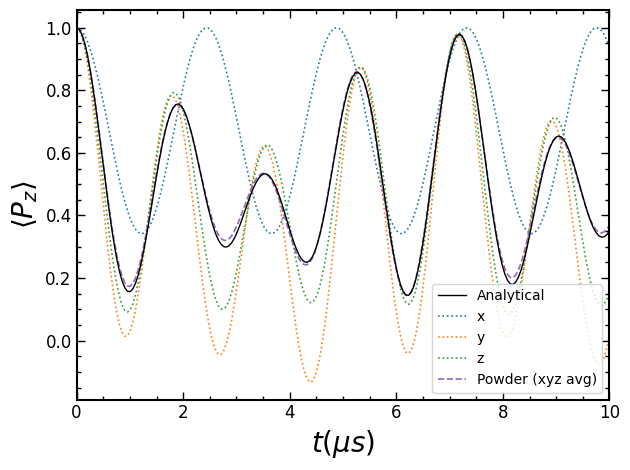

In [45]:
fig, ax = plt.subplots(1,1)

# ax.plot(tlist_us, FmuF(tlist, r), color='k', label=r'Analytical', linestyle='-')

# ax.plot(tlist_us, signal_FmuF_x, label='x', linestyle='-.')
# ax.plot(tlist_us, signal_FmuF_y, label='y', linestyle='--')
# ax.plot(tlist_us, signal_FmuF_z, label='z', linestyle=':')

# ax.plot(tlist_us, (signal_FmuF_x+signal_FmuF_y+signal_FmuF_z)/3, label='Powder', linestyle='--')

# ax.plot(tlist_us, signal_FmuF_xyz, label='Powder (xyz)', linestyle='-.')
# ax.plot(tlist_us, signal_FmuF_zcw, label='Powder (zcw)', linestyle='-.')

# Reference curve (Solid black, prominent width)
ax.plot(
    tlist_us, FmuF(tlist, r), 
    color='black', label='Analytical', ls='-', lw=1.0, zorder=5
)

# Individual directional axes (x, y, z) — subtle colors, thin dashed/dotted
ax.plot(tlist_us, signal_FmuF_x, label='x', color='#1f77b4', ls=':', lw=1.2)
ax.plot(tlist_us, signal_FmuF_y, label='y', color='#ff7f0e', ls=':', lw=1.2)
ax.plot(tlist_us, signal_FmuF_z, label='z', color='#2ca02c', ls=':', lw=1.2)

# Powder averages — distinct dash patterns and medium weight
ax.plot(
    tlist_us, (signal_FmuF_x + signal_FmuF_y + signal_FmuF_z) / 3, 
    label='Powder (xyz avg)', color='#9467bd', ls='--', lw=1.2
)
# ax.plot(
#     tlist_us, signal_FmuF_xyz, 
#     label='Powder (xyz)', color='#9467bd', ls='-.', linewidth=1.2
# )
# ax.plot(
#     tlist_us, signal_FmuF_zcw, 
#     label='Powder (zcw)', color='#d62728', ls=(0, (3, 1, 1, 1)), lw=1.2
# )


ax.legend()
fancy_style_axes(ax)

ax.set_xlabel(r'$t (\mu s)$', fontsize=20)
ax.set_ylabel(r'$\left<P_z\right>$', fontsize=20)

ax.set_xlim([0, 10])

plt.tight_layout()
figname='FmuF_signal.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()